In [26]:
from pathlib import Path
try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive")
    DRIVE = Path("/content/drive/MyDrive/NUIN")
    REPO = Path("/content/motionnet_cnn")
    if REPO.exists():
        !cd {REPO} && git pull
    else:
        !git clone https://github.com/guardomayas/motionnet.git {REPO}
    !pip install -q -e {REPO}
    import site, importlib
    site.main(); importlib.invalidate_caches()

from motionnet.paths import setup
DATA_PATH, CKPT_DIR = setup(IN_COLAB)
print(DATA_PATH, len(list(DATA_PATH.glob("*.iml"))), "images")

/home/guardomayas/NUIN/van_hateren/vanhateren_iml 4167 images


In [ ]:
import motionnet
import json
from motionnet.dataset import (GetNaturalMovies, DiskCachedDataset, movie_fingerprint,
                               PrefilterConfig, ensure_cache, sigma_for,
                               split_images, animate_sample)
from motionnet.models import MotionCNN 


import numpy as np
import math
from torch.utils.data import DataLoader
from tqdm import tqdm
from IPython.display import HTML, display
from pathlib import Path

import torch.nn as nn
import torch.nn.functional as F
import torch
from torch.utils.data import DataLoader

import os
import seaborn as sns

from tqdm import tqdm

sns.set_context("talk")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")   
print(f"Using device: {device}")
print(os.getcwd())
print(motionnet.__file__)   # should end in src/motionnet/__init__.py

Using device: cpu
/home/guardomayas/NUIN/motionnet/notebooks
/home/guardomayas/NUIN/motionnet/src/motionnet/__init__.py


In [28]:
## GLOBAL VARS
SHOW_ANIM  = False
COEFF_DIR  = (DRIVE / "motionnet/cache") if IN_COLAB else Path("/home/guardomayas/NUIN/motionnet/data/coeffs")
MOVIE_DIR  = Path("/content/movie_cache") if IN_COLAB else COEFF_DIR
MOVIE_DIR.mkdir(parents=True, exist_ok=True)

CACHE_DIR = MOVIE_DIR / "movies_train"
N_IMAGES = 100
RNG      = np.random.default_rng(0)



In [ ]:


CFG = dict(eye_size=31, spacing_px=None, blur_px=13, start_jitter=40,
           contrast_range=None, noise_std=0.0,
           frames_per_segment=150*1.5, fps=150,
           vel_std_deg_s=(120, 70), samples_per_image=6)

# No hand-copied formula: same function __init__ uses.
PRE = PrefilterConfig(sigma_px=sigma_for(CFG["blur_px"]))

train_files, val_files = split_images(DATA_PATH, n_images=N_IMAGES,
                                      val_frac=0.2, stride=1)

CACHE_DIR.mkdir(parents=True, exist_ok=True)
tag = f"blur{CFG['blur_px']}_v{int(PRE.sigma_px * 100)}"
train_cache = CACHE_DIR / f"train_n{len(train_files)}_{tag}.npy"
val_cache   = CACHE_DIR / f"val_n{len(val_files)}_{tag}.npy"

# Rebuilds if the cache is missing, stale, or a half-written corpse.
ensure_cache(train_files, train_cache, PRE)
ensure_cache(val_files, val_cache, PRE)

# def movie_fingerprint(seed, CFG, PRE, n):
#     return json.dumps({"cfg": CFG, "pre": PRE.__dict__, "seed": seed, "n": n},
#                       sort_keys=True, default=str)

train_ds = DiskCachedDataset(
    GetNaturalMovies(files=train_files, coeff_cache=train_cache, seed=1, **CFG),
    cache_dir=MOVIE_DIR / "movies_train",
    fingerprint=movie_fingerprint(1, CFG, PRE, len(train_files)),
    on_mismatch="rebuild")

val_ds = DiskCachedDataset(
    GetNaturalMovies(files=val_files, coeff_cache=val_cache, seed=99, **CFG),
    cache_dir= MOVIE_DIR / "movies_val",
    fingerprint=movie_fingerprint(99, CFG, PRE, len(val_files)),
    on_mismatch="rebuild")

print("Training data: ", len(train_ds))
print("Validation data: ", len(val_ds))


Training data:  480
Validation data:  120


/tmp/ipykernel_245594/1875632794.py:31: RuntimeWarning: excursion budget is tight on x: limit 515 px is 2.1 sigma of the position spread (246 px). In 'reject' mode this means many redraws. Reduce vel_std_deg_s (now (120.0, 70.0)), frames_per_segment (now 225), or start_jitter (now 40).
  GetNaturalMovies(files=train_files, coeff_cache=train_cache, seed=1, **CFG),
/tmp/ipykernel_245594/1875632794.py:31: RuntimeWarning: excursion budget is tight on y: limit 259 px is 1.8 sigma of the position spread (144 px). In 'reject' mode this means many redraws. Reduce vel_std_deg_s (now (120.0, 70.0)), frames_per_segment (now 225), or start_jitter (now 40).
  GetNaturalMovies(files=train_files, coeff_cache=train_cache, seed=1, **CFG),
/tmp/ipykernel_245594/1875632794.py:37: RuntimeWarning: excursion budget is tight on x: limit 515 px is 2.1 sigma of the position spread (246 px). In 'reject' mode this means many redraws. Reduce vel_std_deg_s (now (120.0, 70.0)), frames_per_segment (now 225), or star

In [30]:
base = GetNaturalMovies(files=train_files, coeff_cache=train_cache, seed=1, **CFG)
for i in range(300):
    base[i]
print(f"acceptance {100*base.acceptance_rate:.0f}%  fallbacks {base._n_fallback}/{base._n_samples}")
v = torch.cat([train_ds[i]["vel_deg_s"][ slice(train_ds.gray_frames, None)] for i in range(len(train_ds))]).cpu()
print("empirical std (deg/s):", v.std(0).cpu().numpy().round(1), "vs nominal", train_ds.vel_std_deg_s)

/tmp/ipykernel_245594/3458203595.py:1: RuntimeWarning: excursion budget is tight on x: limit 515 px is 2.1 sigma of the position spread (246 px). In 'reject' mode this means many redraws. Reduce vel_std_deg_s (now (120.0, 70.0)), frames_per_segment (now 225), or start_jitter (now 40).
  base = GetNaturalMovies(files=train_files, coeff_cache=train_cache, seed=1, **CFG)
/tmp/ipykernel_245594/3458203595.py:1: RuntimeWarning: excursion budget is tight on y: limit 259 px is 1.8 sigma of the position spread (144 px). In 'reject' mode this means many redraws. Reduce vel_std_deg_s (now (120.0, 70.0)), frames_per_segment (now 225), or start_jitter (now 40).
  base = GetNaturalMovies(files=train_files, coeff_cache=train_cache, seed=1, **CFG)


acceptance 88%  fallbacks 0/300
empirical std (deg/s): [117.5  66.3] vs nominal (120.0, 70.0)


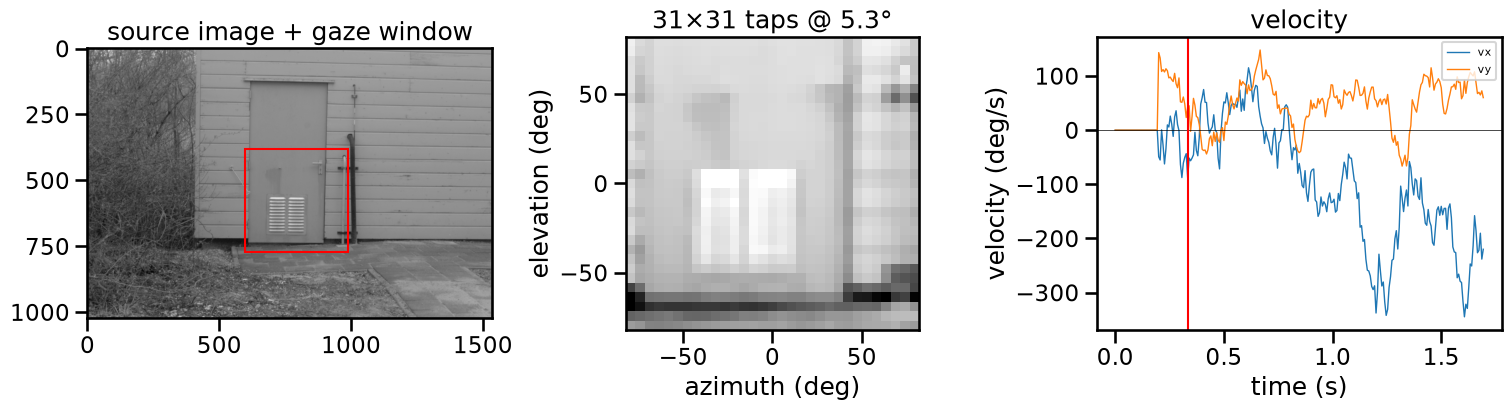

In [ ]:
anim = animate_sample(train_ds, idx=1, stride=3)

if SHOW_ANIM:
    display(HTML(anim.to_jshtml()))
else:
    anim._draw_frame(20)      # pass a value from the frames iterable, not an index 
    display(anim._fig)

# #     # plt.close(anim._fig)          # suppress the static figure

## Setting up a CNN

In [32]:
class ResidentDataset(torch.utils.data.Dataset):
    """Movies and targets held as two tensors, served with the original keys."""
    def __init__(self, movies, targets, contrasts_rms):
        self.movies, self.targets, self.contrasts_rms = movies, targets, contrasts_rms

    def __len__(self):
        return self.movies.shape[0]

    def __getitem__(self, i):
        return {"movie": self.movies[i].float(),
                "vel_deg_s": self.targets[i],
                "contrast_rms": self.contrasts_rms[i]}

@torch.no_grad()
def materialize(ds, device=None, dtype=torch.float16):
    """One pass over the cached dataset into a single resident tensor."""
    s0 = ds[0]
    movies  = torch.empty((len(ds), *s0["movie"].shape), dtype=dtype)
    targets = torch.empty((len(ds), *s0["vel_deg_s"].shape), dtype=torch.float32)
    contrasts_rms = torch.empty((len(ds), *s0["contrast_rms"].shape), dtype=torch.float32)
    for i in tqdm(range(len(ds)), desc="materializing"):
        s = ds[i]
        movies[i]  = s["movie"].to(dtype)
        targets[i] = s["vel_deg_s"]
        contrasts_rms[i] = s["contrast_rms"]
        
    if device is not None:
        movies, targets, contrasts_rms = movies.to(device), targets.to(device), contrasts_rms.to(device)
    return ResidentDataset(movies, targets, contrasts_rms)

train_mem = materialize(train_ds, device=device)
val_mem   = materialize(val_ds,   device=device)

train_dl = DataLoader(train_mem, batch_size=32, shuffle=True, drop_last=True,
                      num_workers=0)   # already on GPU; workers would be worse
val_dl   = DataLoader(val_mem, batch_size=32, num_workers=0)

materializing: 100%|██████████| 120/120 [00:00<00:00, 519.25it/s]


In [ ]:
GRAY  = train_ds.gray_frames          # hoisted: the loaders no longer touch train_ds

probe = MotionCNN(
                 rf_size_1=5,
                 rf_size_2=5,
                 fps = train_ds.fps,
                 num_subunits_1=8,
                 num_subunits_2=8,
                 out_gain=1.0,
                 initial_threshold=0.0,
                 initial_gain=1.0,
                 input_noise_std = 0.1,
                 layer_noise_std = 0.1
).to(device)

support: 32 frames = 207 ms
rank: 8 of 8
condition number: 16.411417535364563


In [36]:
print("train batches per epoch:", len(train_dl))
print("val batches per epoch:", len(val_dl))
print("train samples:", len(train_dl.dataset))
print("val samples:", len(val_dl.dataset))

train batches per epoch: 15
val batches per epoch: 4
train samples: 480
val samples: 120


## Overfit one batch


In [37]:
loss_fn = nn.MSELoss()
probe_opt = torch.optim.AdamW(probe.parameters(), lr=1e-3, weight_decay=0.0)

batch  = next(iter(train_dl))
movie  = batch["movie"].to(device)

VALID = slice(GRAY + probe.max_delay - 1, None)
v = np.concatenate([train_ds[i]["vel_deg_s"][VALID].numpy() for i in range(len(train_ds))])
V_STD = torch.tensor(v.std(0), device=device)     # [116.0, 64.0] deg/s
target = batch["vel_deg_s"].to(device) / V_STD
probe.train()

for step in range(2500):
    pred = probe(movie)
    loss = loss_fn(pred[:, VALID], target[:, VALID])
    probe_opt.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(probe.parameters(), max_norm=1.0)
    probe_opt.step()

    if step % 250 == 0:
        with torch.no_grad():
            t = target[:, VALID]
            print(f"{step:4d}  loss {loss.item():.4f}  R² {1 - loss.item()/t.var().item():.3f}")

del probe, probe_opt
torch.cuda.empty_cache()

t = target[:, VALID]
print("target var:", t.var().item())                    # predict-mean baseline
print("R²:", 1 - loss.item() / t.var().item())
print("pred std:", pred[:, VALID].std().item(), "target std:", t.std().item())
err = (pred[:, VALID] - target[:, VALID]).pow(2).mean((0, 1))
print(1 - err / target[:, VALID].var((0, 1)))


/home/guardomayas/NUIN/motionnet/.venv/lib/python3.11/site-packages/matplotlib/animation.py:916: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


   0  loss 0.9890  R² -0.026


KeyboardInterrupt: 

## Full training loop

In [ ]:
v = torch.cat([train_ds[i]["vel_deg_s"][VALID] for i in range(len(train_ds))]).cpu()
V_STD = v.std(0).to(device)                       # ~[116, 64] deg/s
print("V_STD:", V_STD.cpu().numpy().round(1))

# and once, in the first batch:
assert 0.9 < target[:, VALID].std().item() < 1.1, "targets not standardized"

V_STD: [116.9  66.2]


In [ ]:
SCALE_FREE = {                      # dims must match what forward() normalizes over
    "spatial_kernel": (1, 2, 3),    # per layer-1 channel
    "temporal_w":     (1,),         # per row; phi = w @ B.T is normalized downstream
    "layer2.weight":  (1, 2, 3),    # per layer-2 channel
    "readout":        (1,),         # per output row
}

@torch.no_grad()
def renormalize(model):
    params = dict(model.named_parameters())
    for name, dims in SCALE_FREE.items():
        p = params[name]
        p.div_(torch.linalg.vector_norm(p, dim=dims, keepdim=True) + 1e-8)

In [ ]:
LAMBDA_SP  = 0.0      # spatial Laplacian (optional at 1 tap/column)
LAMBDA_T   = 0.0   # temporal smoothness
LAMBDA_1   = 1e-3      # layer-1 rate; > 0 only when interpreting gain_1 (ON/OFF)
LAMBDA_2   = 4e-2      # layer-2 rate; baseline 0, then sweep
WARMUP     = 50       # epochs to ramp rate costs from 0
num_epochs = 400

torch.manual_seed(1)
model = MotionCNN(
                 rf_size_1=5,
                 rf_size_2=5,
                 fps = train_ds.fps,
                 num_subunits_1=10,
                 num_subunits_2=8,
                 out_gain=1.0,
                 initial_threshold=0.0,
                 initial_gain=1.0,
                 input_noise_std=0.10 * math.sqrt(train_ds.fps / 75), #SNR ∝ σ⁻¹√fps,
                 layer_noise_std = 0.1)


GRAY  = train_ds.gray_frames
VALID = slice(GRAY + model.max_delay - 1, None)
# VALID = slice(GRAY, None)
loss_fn = nn.MSELoss()

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=0.0)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-4)


def normed(w, dims):
    return w / (torch.linalg.vector_norm(w, dim=dims, keepdim=True) + 1e-8)


def run_epoch(model, loader, optimizer=None, ramp=1.0):
    is_train = optimizer is not None
    model.train(is_train)
    keys = ("total", "mse", "rate1", "rate2")
    sums = {k: torch.zeros((), device=device) for k in keys}
    err = torch.zeros(2, device=device); sq = torch.zeros(2, device=device); n_frames = 0; n = 0

    for batch in loader:
        movie  = batch["movie"].to(device)
        target = batch["vel_deg_s"].to(device) / V_STD     # same key as the probe

        pred = model(movie)
        p, t = pred[:, VALID], target[:, VALID]
        mse = loss_fn(p, t)

        total = mse
        if LAMBDA_SP: total = total + LAMBDA_SP * laplacian_penalty(normed(model.spatial_kernel, (1, 2, 3)))
        if LAMBDA_T:  total = total + LAMBDA_T  * temporal_smoothness(normed(model.temporal_kernel, (1, 2)))
        total = total + ramp * (LAMBDA_1 * model._subunit_rate + LAMBDA_2 * model.layer2_rate)

        if is_train:
            optimizer.zero_grad()
            total.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            renormalize(model)

        B = movie.shape[0]; n += B
        for k, val in zip(keys, (total, mse, model._subunit_rate, model.layer2_rate)):
            sums[k] += val.detach() * B
        err += (p - t).detach().pow(2).sum((0, 1)); sq += t.pow(2).sum((0, 1)); n_frames += t.shape[0] * t.shape[1]

    out = {k: (s / n).item() for k, s in sums.items()}
    r2 = (1 - err / sq).cpu().numpy()          # targets are zero-mean by construction
    out["r2_x"], out["r2_y"] = float(r2[0]), float(r2[1])
    return out


history = {"train": [], "val": [], "lr": []}
epoch_bar = tqdm(range(1, num_epochs + 1), desc="Training")
for epoch in epoch_bar:
    ramp = min(1.0, epoch / WARMUP)
    tr = run_epoch(model, train_dl, optimizer, ramp)
    
    with torch.no_grad():
        va = run_epoch(model, val_dl, None, ramp)

    history["lr"].append(optimizer.param_groups[0]["lr"]); sched.step()
    history["train"].append(tr); history["val"].append(va)

    if epoch == 1 or epoch % 20 == 0 or epoch == num_epochs:
        # epoch_bar.set_postfix_str(
        #             f"mse {tr['mse']:.3f}/{va['mse']:.3f} | "
        #             f"R² x{va['r2_x']:.3f} y{va['r2_y']:.3f} | "
        #             f"rate {va['rate1']:.3f}/{va['rate2']:.3f}"
        #         ) 
        tqdm.write(f"{epoch:3d} | mse {tr['mse']:.3f}/{va['mse']:.3f} | "
                   f"R² val x {va['r2_x']:.3f} y {va['r2_y']:.3f} | "
                   f"rate1 {va['rate1']:.3f} rate2 {va['rate2']:.3f}")

Training:   0%|          | 1/400 [00:02<16:35,  2.50s/it]

  1 | mse 0.872/0.681 | R² val x 0.262 y 0.377 | rate1 0.453 rate2 0.405


Training:   5%|▌         | 20/400 [00:48<15:30,  2.45s/it]

 20 | mse 0.286/0.302 | R² val x 0.706 y 0.690 | rate1 1.120 rate2 0.651


Training:  10%|█         | 40/400 [01:37<14:41,  2.45s/it]

...

360 | mse 0.169/0.182 | R² val x 0.822 y 0.815 | rate1 1.650 rate2 0.546


Training:  95%|█████████▌| 380/400 [15:30<00:49,  2.45s/it]

380 | mse 0.169/0.182 | R² val x 0.822 y 0.815 | rate1 1.659 rate2 0.547


Training: 100%|██████████| 400/400 [16:19<00:00,  2.45s/it]

400 | mse 0.169/0.182 | R² val x 0.822 y 0.815 | rate1 1.665 rate2 0.542


R² over frames past the transient: 0.837


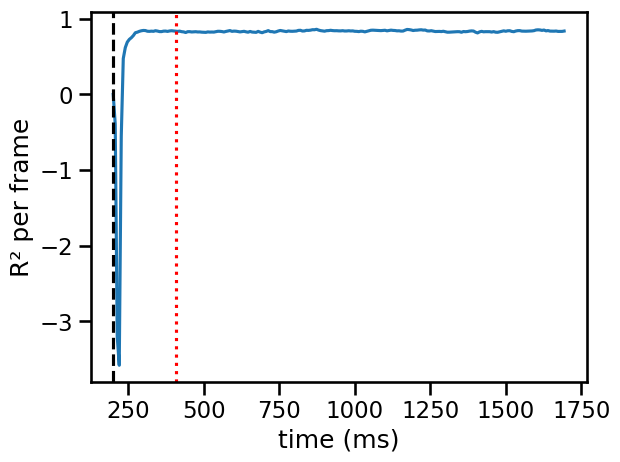

In [ ]:
@torch.no_grad()
def mse_by_frame(model, loader, noise=False):
    model.eval()
    s_in, s_1 = model.input_noise_std, model.layer_noise_std
    if not noise: model.input_noise_std = model.layer_noise_std = 0.0
    num = den = 0
    for b in loader:
        movie = b["movie"].to(device)
        t = b["vel_deg_s"].to(device) / V_STD
        p = model(movie)
        num = num + (p - t).pow(2).sum((0, 2))      # (T,)
        den = den + t.pow(2).sum((0, 2))
    model.input_noise_std, model.layer_noise_std = s_in, s_1
    return (1 - num / den).cpu().numpy()            # R² per frame

r2_t = mse_by_frame(model, val_dl)
plt.plot(np.arange(len(r2_t)) / train_ds.fps * 1000, r2_t)
plt.axvline(GRAY / train_ds.fps * 1000, ls="--", c="k")
plt.axvline((GRAY + model.max_delay - 1) / train_ds.fps * 1000, ls=":", c="r")
plt.xlabel("time (ms)"); plt.ylabel("R² per frame")
print("R² over frames past the transient:",
      r2_t[GRAY + model.max_delay - 1:].mean().round(3))

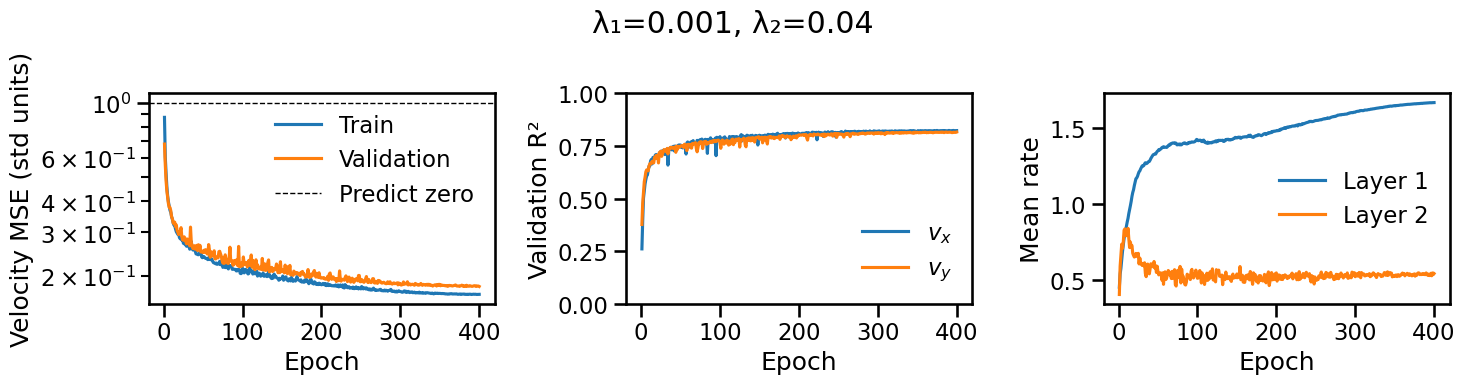

In [ ]:
import pandas as pd

epochs = range(1, len(history["train"]) + 1)


tr = pd.DataFrame(history["train"])
va = pd.DataFrame(history["val"])
epochs = range(1, len(tr) + 1)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].plot(epochs, tr["mse"], label="Train")
ax[0].plot(epochs, va["mse"], label="Validation")
ax[0].axhline(1.0, ls="--", lw=1, c="k", label="Predict zero")
ax[0].set(xlabel="Epoch", ylabel="Velocity MSE (std units)", yscale="log")

ax[1].plot(epochs, va["r2_x"], label="$v_x$")
ax[1].plot(epochs, va["r2_y"], label="$v_y$")
ax[1].set(xlabel="Epoch", ylabel="Validation R²", ylim=(0, 1))

ax[2].plot(epochs, va["rate1"], label="Layer 1")
ax[2].plot(epochs, va["rate2"], label="Layer 2")
ax[2].set(xlabel="Epoch", ylabel="Mean rate")

for a in ax:
    a.legend(frameon=False)
fig.suptitle(f"λ₁={LAMBDA_1:g}, λ₂={LAMBDA_2:g}")
fig.tight_layout()
plt.show()

In [ ]:
model.eval()
with torch.no_grad():
    model(next(iter(val_dl))["movie"].to(device))
snr = model._l1_std / model.layer_noise_std
print("layer-1 signal std / noise std, per channel:", snr.cpu().numpy().round(1))

layer-1 signal std / noise std, per channel: [14.9 10.  20.6 10.3 12.  21.7 32.  12.5  9.7 30.5]


In [ ]:
import itertools
@torch.no_grad()
def snr_report(model, loader, n_batches=20):
    model.eval()
    m = torch.cat([b["movie"][:, VALID] for b in itertools.islice(iter(loader), n_batches)]).to(device)
    s_in = model.input_noise_std
    print(f"input  static SNR {m.std() / s_in:.2f}   "
          f"motion SNR {m.diff(dim=1).std() / (s_in * 2**0.5):.2f}")

    l1 = []
    for b in itertools.islice(iter(loader), n_batches):
        model(b["movie"].to(device))
        l1.append(model._l1_std)
    l1 = torch.stack(l1).mean(0) / model.layer_noise_std
    print("layer1 SNR per channel:", l1.cpu().numpy().round(1))

snr_report(model, val_dl)

input  static SNR 4.03   motion SNR 0.26
layer1 SNR per channel: [19.1 12.2 23.6 11.9 13.2 23.9 40.9 17.  10.4 33.5]


In [ ]:
@torch.no_grad()
def layer2_tuning(model, loader, n_batches=30, n_dir=8):
    model.eval()
    s_in, s_1 = model.input_noise_std, model.layer_noise_std
    model.input_noise_std = model.layer_noise_std = 0.0

    R, V = [], []
    for b in itertools.islice(iter(loader), n_batches):
        movie = b["movie"].to(device)
        model(movie)
        B, T = movie.shape[:2]
        R.append(model._pool.view(B, T, -1)[:, VALID].flatten(0, 1).cpu())
        V.append(b["vel_deg_s"][:, VALID].flatten(0, 1).cpu())       # raw deg/s
    model.input_noise_std, model.layer_noise_std = s_in, s_1

    R, V = torch.cat(R), torch.cat(V)
    speed = (V / V_STD.cpu()).norm(dim=1)                            # standardized, for the split
    fast = speed > speed.median()
    ang = torch.atan2(V[fast, 1], V[fast, 0])                        # physical angle
    idx = ((ang + math.pi) / (2 * math.pi) * n_dir).long().clamp(max=n_dir - 1)
    tun = torch.stack([R[fast][idx == d].mean(0) for d in range(n_dir)])   # (n_dir, N2)

    pd = tun.argmax(0); nd = (pd + n_dir // 2) % n_dir
    ch = torch.arange(tun.shape[1])
    Rp, Rn = tun[pd, ch], tun[nd, ch]
    return dict(pref_deg=(pd * 360 / n_dir - 180 + 180 / n_dir).numpy(),
                dsi=((Rp - Rn) / (Rp + Rn + 1e-8)).numpy().round(2),
                mean_rate=R.mean(0).numpy().round(2),
                tuning=tun.numpy())
    

res =  layer2_tuning(model, val_dl, n_batches=30, n_dir=8)
t = torch.tensor(res["tuning"])                  # (n_dir, N2)
print(res)
print(torch.corrcoef(t.T).numpy().round(2))      # channel-by-channel similarity of tuning

{'pref_deg': array([-157.5,  -67.5,   22.5, -157.5,  -67.5,  157.5,  112.5,   22.5],
      dtype=float32), 'dsi': array([0.  , 0.98, 0.94, 0.98, 0.99, 0.95, 0.98, 0.96], dtype=float32), 'mean_rate': array([0.  , 0.45, 0.37, 0.41, 0.44, 0.42, 0.64, 0.54], dtype=float32), 'tuning': array([[0.        , 0.89209133, 0.03208205, 1.3301063 , 0.75673926,
        1.1516422 , 0.19506867, 0.02792633],
       [0.        , 1.5011715 , 0.1380232 , 0.63488716, 1.345092  ,
        0.5346931 , 0.0326631 , 0.19352613],
       [0.        , 1.513712  , 0.37871537, 0.18369636, 1.4520154 ,
        0.18966113, 0.02467068, 0.6808309 ],
       [0.        , 0.90557426, 0.849822  , 0.02892135, 0.9221671 ,
        0.03254373, 0.1526122 , 1.475845  ],
       [0.        , 0.18378964, 1.0796958 , 0.01666605, 0.15629889,
        0.03762924, 1.1237011 , 1.5607511 ],
       [0.        , 0.02469039, 0.6142638 , 0.0970444 , 0.00974379,
        0.21135646, 1.9936702 , 0.7300115 ],
       [0.        , 0.01721039, 0.3211536

In [ ]:
n_dir = 8
th = torch.linspace(-math.pi, math.pi, n_dir + 1)[:-1] + math.pi / n_dir
t = torch.tensor(res["tuning"])                          # (n_dir, N2)
z = (t * torch.exp(1j * th)[:, None]).sum(0)
pref = torch.rad2deg(torch.angle(z))                     # preferred direction
ldsi = z.abs() / t.sum(0)                                # vector DSI, 0 = untuned, 1 = single direction

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt


@torch.no_grad()
def compute_val_r2_per_movie(
    model,
    val_loader,
    device,
):
    model.eval()

    r2_per_seq = []
    pred_all = []
    target_all = []

    for batch in val_loader:
        movie = batch["movie"].to(device)
        target = batch["vel_deg_s"].to(device)/V_STD  # raw px/s, (B, T, 2)
        valid =  slice(train_ds.gray_frames + model.max_delay - 1, None)
        pred = model(movie)                   # normalized, (B, T, 2)
        pred = pred[:, valid]
        target = target[:, valid]

        # Per movie R² over both vx and vy together
        ss_res = ((target - pred) ** 2).sum(dim=(1, 2))
        target_mean = target.mean(dim=(1, 2), keepdim=True)
        ss_tot = ((target - target_mean) ** 2).sum(dim=(1, 2))

        r2 = 1.0 - ss_res / (ss_tot + 1e-8)

        r2_per_seq.extend(r2.detach().cpu().numpy())
        pred_all.append(pred.detach().cpu())
        target_all.append(target.detach().cpu())

    r2_per_seq = np.asarray(r2_per_seq)
    pred_all = torch.cat(pred_all, dim=0)        # (Nval, T-gray, 2)
    target_all = torch.cat(target_all, dim=0)

    return r2_per_seq, pred_all, target_all

r2_per_seq, pred_val, target_val = compute_val_r2_per_movie(
    model=model,
    val_loader= val_dl,
    device=device,
)

mean_r2 = np.mean(r2_per_seq)
sem_r2 = np.std(r2_per_seq, ddof=1) / np.sqrt(len(r2_per_seq))

print("Mean R²:", mean_r2)
print("SEM R²:", sem_r2)
print("N validation movies:", len(r2_per_seq))
print("Min/Max R²:", r2_per_seq.min(), r2_per_seq.max())

Mean R²: 0.76125693
SEM R²: 0.005532514863205026
N validation movies: 480
Min/Max R²: -0.113865376 0.93777657


In [ ]:
# import scipy.stats as st
# print(st.spearmanr(r2_per_seq, rms_per_movie))       # scene contrast
# print(st.spearmanr(r2_per_seq, speed_per_movie))     # mean |v|

/tmp/ipykernel_34505/2984844139.py:144: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


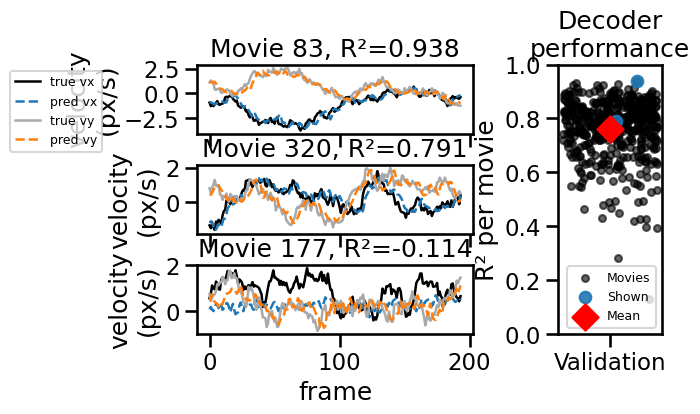

In [ ]:
from matplotlib.gridspec import GridSpec


def plot_validation_summary_two_columns(
    r2_per_seq,
    pred_val,
    target_val,
    n_examples=3,
    example_mode="best",  # "best", "worst", or "mixed"
    figsize=(11, 7),
):
    # Convert tensors to numpy if needed
    if hasattr(pred_val, "detach"):
        pred_val_np = pred_val.detach().cpu().numpy()
    else:
        pred_val_np = np.asarray(pred_val)

    if hasattr(target_val, "detach"):
        target_val_np = target_val.detach().cpu().numpy()
    else:
        target_val_np = np.asarray(target_val)

    r2_per_seq = np.asarray(r2_per_seq)

    # Choose example indices
    order = np.argsort(r2_per_seq)

    if example_mode == "best":
        example_idxs = order[-n_examples:][::-1]
    elif example_mode == "worst":
        example_idxs = order[:n_examples]
    elif example_mode == "mixed":
        example_idxs = np.array([
            order[-1],
            order[len(order) // 2],
            order[0],
        ])
        example_idxs = example_idxs[:n_examples]
    else:
        raise ValueError("example_mode must be 'best', 'worst', or 'mixed'.")

    mean_r2 = np.mean(r2_per_seq)
    sem_r2 = np.std(r2_per_seq, ddof=1) / np.sqrt(len(r2_per_seq))

    # Figure layout
    fig = plt.figure(figsize=figsize)
    gs = GridSpec(
        nrows=len(example_idxs),
        ncols=2,
        width_ratios=[3.2, 1.2],
        wspace=0.45,
        hspace=0.45,
        figure=fig,
    )

    # -----------------------------
    # Left column: example traces
    # -----------------------------
    for row, idx in enumerate(example_idxs):
        ax = fig.add_subplot(gs[row, 0])

        pred = pred_val_np[idx]
        target = target_val_np[idx]

        t = np.arange(target.shape[0])

        ax.plot(t, target[:, 0], label="true vx", linewidth=1.8, c='k')
        ax.plot(t, pred[:, 0], label="pred vx", linewidth=1.8, linestyle="--")

        ax.plot(t, target[:, 1], label="true vy", linewidth=1.8, c='darkgray')
        ax.plot(t, pred[:, 1], label="pred vy", linewidth=1.8, linestyle="--")

        ax.set_title(f"Movie {idx}, R²={r2_per_seq[idx]:.3f}")
        ax.set_ylabel("velocity\n(px/s)")

        if row == len(example_idxs) - 1:
            ax.set_xlabel("frame")
        else:
            ax.set_xticklabels([])

        if row == 0:
            ax.legend(ncol=1, fontsize=9, loc="upper left",
                      bbox_to_anchor=(-.7, 1.0),)

    # -----------------------------
    # Right column: R² scatter plot
    # -----------------------------
    ax_r2 = fig.add_subplot(gs[:, 1])

    x0 = 0
    rng = np.random.default_rng(0)
    x_jitter = x0 + rng.uniform(-0.15, 0.15, size=len(r2_per_seq))

    ax_r2.scatter(
        x_jitter,
        r2_per_seq,
        alpha=0.6,
        s=25,
        c="k",
        label="Movies",
    )

    # Highlight selected examples
    ax_r2.scatter(
        x_jitter[example_idxs],
        r2_per_seq[example_idxs],
        alpha=0.9,
        s=70,
        c="tab:blue",
        label="Shown",
    )

    # Mean marker + SEM
    ax_r2.scatter(
        x0,
        mean_r2,
        s=180,
        marker="D",
        c="red",
        label="Mean",
        zorder=5,
    )

    ax_r2.errorbar(
        x0,
        mean_r2,
        yerr=sem_r2,
        fmt="none",
        ecolor="red",
        capsize=5,
        linewidth=2,
        zorder=4,
    )

    ax_r2.axhline(0, linestyle="--", linewidth=1)
    ax_r2.set_xticks([x0])
    ax_r2.set_xticklabels(["Validation"])
    ax_r2.set_ylim(0, 1)
    ax_r2.set_ylabel("R² per movie")
    ax_r2.set_title("Decoder\nperformance")
    ax_r2.legend(fontsize=9, loc="lower right")

    # fig.suptitle("Validation performance summary", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

    return fig

fig = plot_validation_summary_two_columns(
    r2_per_seq=r2_per_seq,
    pred_val=pred_val,
    target_val=target_val,
    n_examples=3,
    example_mode="mixed",
    figsize=(6, 3.5),
)

In [ ]:
import numpy as np
from scipy.signal import convolve2d

def temporal_kernels(cnn):
    """(N1, D) kernels in plot orientation: lag 0 LAST, matching t_ms."""
    phi = cnn.temporal_w @ cnn.tbasis.T                 # (N1, D), lag 0 first
    phi = phi / (phi.norm(dim=1, keepdim=True) + 1e-8)  # same as forward()
    return phi.flip(-1).detach().cpu().numpy()          # lag 0 last

def acceptance_kernel(sigma_taps, truncate=3.0):
    """Ommatidial acceptance function sampled on the tap lattice."""
    r = max(1, int(round(truncate * sigma_taps)))
    ax = np.arange(-r, r + 1)
    g = np.exp(-ax ** 2 / (2 * sigma_taps ** 2))
    k = np.outer(g, g)
    return k / k.sum()


def effective_rf(cnn, dataset, truncate=3.0):
    """W1 convolved with the optics: the object comparable to a measured RF.

    The blur acted upstream of the network, so the learned weights carry no
    optics. Reverse-correlating the model against the *pre-blur* stimulus
    would recover this; convolving is exact because that path is linear.
    """
    sw = cnn.spatial_kernel[:, 0].detach().cpu().clone().numpy()
    sigma_taps = dataset.sigma_px / dataset.spacing_px
    k = acceptance_kernel(sigma_taps, truncate)
    eff = np.stack([convolve2d(w, k, mode="full") for w in sw])
    return eff, sigma_taps

def plot_cnn_subunits_1(cnn, dataset, effective=True, truncate=3.0):
    n_su, max_delay = cnn.num_subunits_1, cnn.max_delay
    tw = temporal_kernels(cnn)

    if effective:
        sw, sigma_taps = effective_rf(cnn, dataset, truncate)
        label = f"W₁ ⊛ O  (σ = {sigma_taps:.2f} taps)"
    else:
        sw = cnn.spatial_kernel[:, 0].detach().cpu().clone().numpy()
        label = "W₁ (weights only)"

    for n in range(n_su):                       # fix sign, push gain to time
        if abs(sw[n].min()) > sw[n].max():
            sw[n], tw[n] = -sw[n], -tw[n]
        s = np.linalg.norm(sw[n])
        sw[n] /= s
        tw[n] *= s

    k = sw.shape[-1]
    half = k * dataset.deg_per_tap / 2
    extent = [-half, half, -half, half]
    t_ms = np.arange(-max_delay + 1, 1) * (1000.0 / dataset.fps)
    vlim, ylim = np.abs(sw).max(), np.abs(tw).max()

    fig, axs = plt.subplots(n_su, 3, figsize=(8, 3.2 * n_su), squeeze=False,
                            gridspec_kw=dict(width_ratios=[1, 1.9, 0.1]))
    for n in range(n_su):
        axs[n, 0].plot(t_ms, tw[n])
        axs[n, 0].axhline(0, ls=":", c="k", lw=0.8)
        axs[n, 0].set_ylim(-ylim, ylim)
        axs[n, 0].tick_params(labelbottom=(n == n_su - 1))
        im = axs[n, 1].imshow(sw[n], cmap="RdBu_r", vmin=-vlim, vmax=vlim,
                              extent=extent, interpolation="nearest")
        axs[n, 1].set_title(f"subunit 1,{n+1}")
        plt.colorbar(im, cax=axs[n, 2])
    axs[-1, 0].set_xlabel(r"$\Delta t$ [ms]")
    axs[-1, 1].set_xlabel("azimuth [deg]")
    fig.suptitle(label)
    fig.tight_layout()
    return fig, axs



def plot_cnn_subunits2(cnn: nn.Module):
    """
    Plot the second layer of subunits of a CNN.
    """
    cnn_filters_2 = cnn.layer2.weight.to("cpu").detach()

    fig, axs = plt.subplots(cnn.num_subunits_2,
                            cnn.num_subunits_1,
                            figsize=(4 * cnn.num_subunits_2,
                                    4 * cnn.num_subunits_1),
                            sharex=True, sharey=True)
    # vlim = abs(cnn_filters_2).max()
    percentile = 99
    vlim = torch.quantile(cnn_filters_2.abs().flatten(), percentile / 100).item()
    for i in range(cnn.num_subunits_2):
        for j in range(cnn.num_subunits_1):
            axs[i, j].imshow(cnn_filters_2[i, j],
                            vmin=-vlim, vmax=vlim, cmap="RdBu_r")

            axs[i, j].set_title('subunit 1,{} $\\to$ 2,{}'.format(j+1,i+1))


(<Figure size 800x3200 with 30 Axes>,
 array([[<Axes: >, <Axes: title={'center': 'subunit 1,1'}>, <Axes: >],
        [<Axes: >, <Axes: title={'center': 'subunit 1,2'}>, <Axes: >],
        [<Axes: >, <Axes: title={'center': 'subunit 1,3'}>, <Axes: >],
        [<Axes: >, <Axes: title={'center': 'subunit 1,4'}>, <Axes: >],
        [<Axes: >, <Axes: title={'center': 'subunit 1,5'}>, <Axes: >],
        [<Axes: >, <Axes: title={'center': 'subunit 1,6'}>, <Axes: >],
        [<Axes: >, <Axes: title={'center': 'subunit 1,7'}>, <Axes: >],
        [<Axes: >, <Axes: title={'center': 'subunit 1,8'}>, <Axes: >],
        [<Axes: >, <Axes: title={'center': 'subunit 1,9'}>, <Axes: >],
        [<Axes: xlabel='$\\Delta t$ [ms]'>,
         <Axes: title={'center': 'subunit 1,10'}, xlabel='azimuth [deg]'>,
         <Axes: >]], dtype=object))

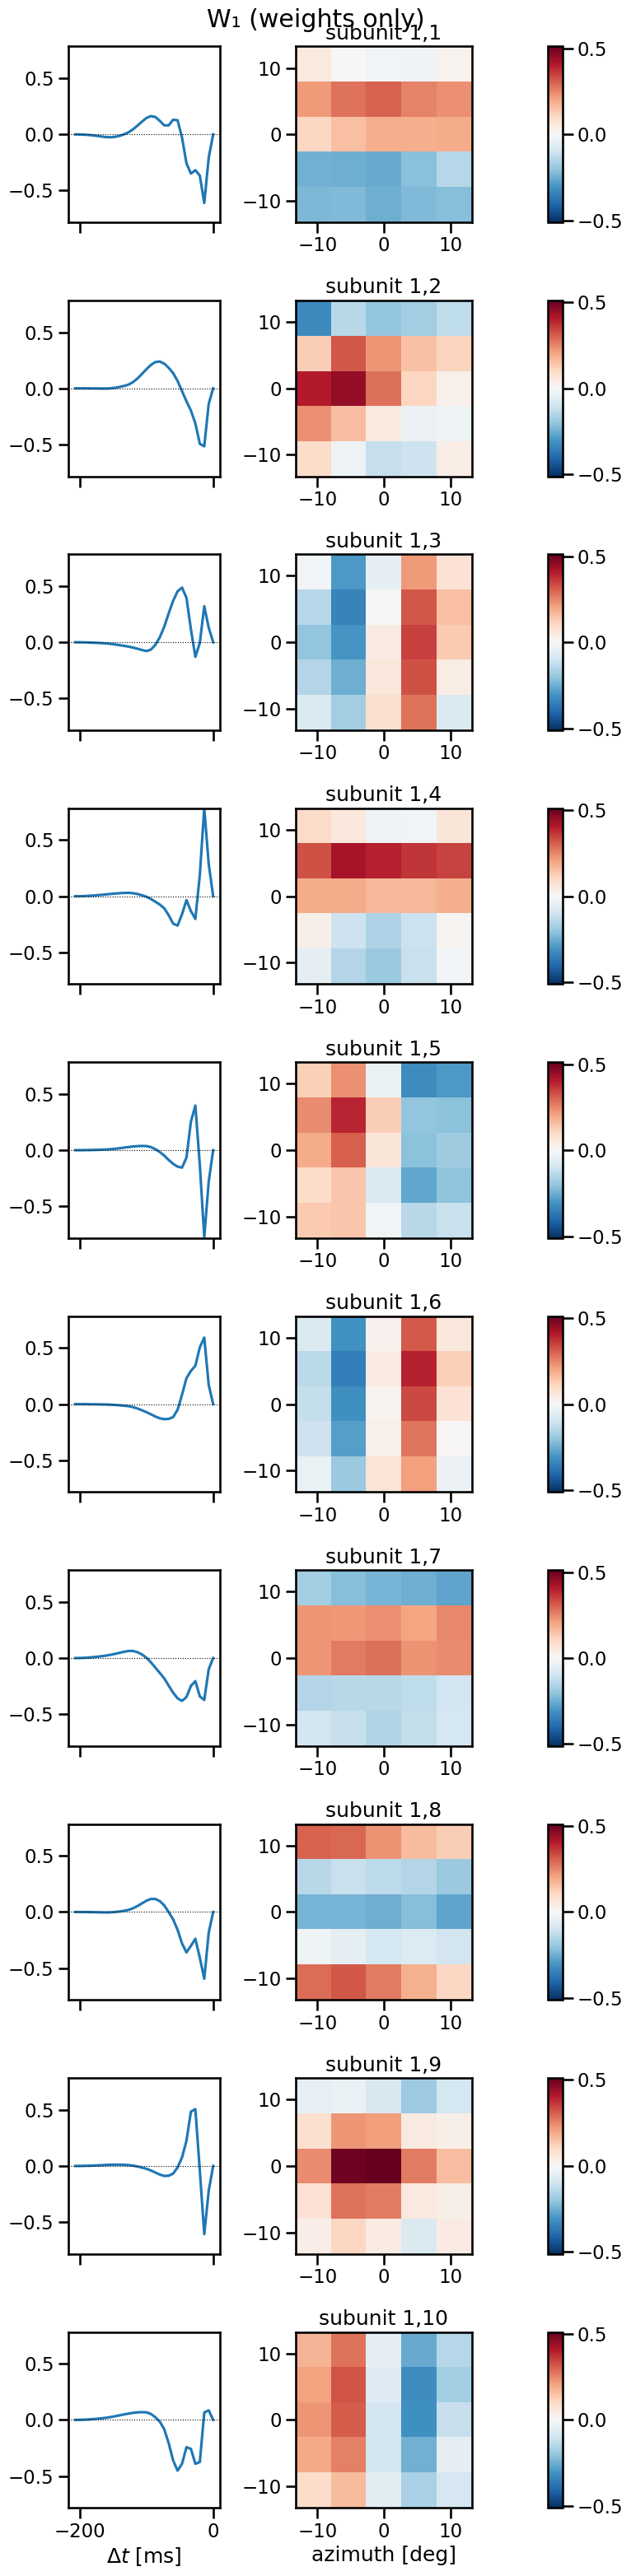

In [ ]:
plot_cnn_subunits_1(model, train_ds, effective=False)

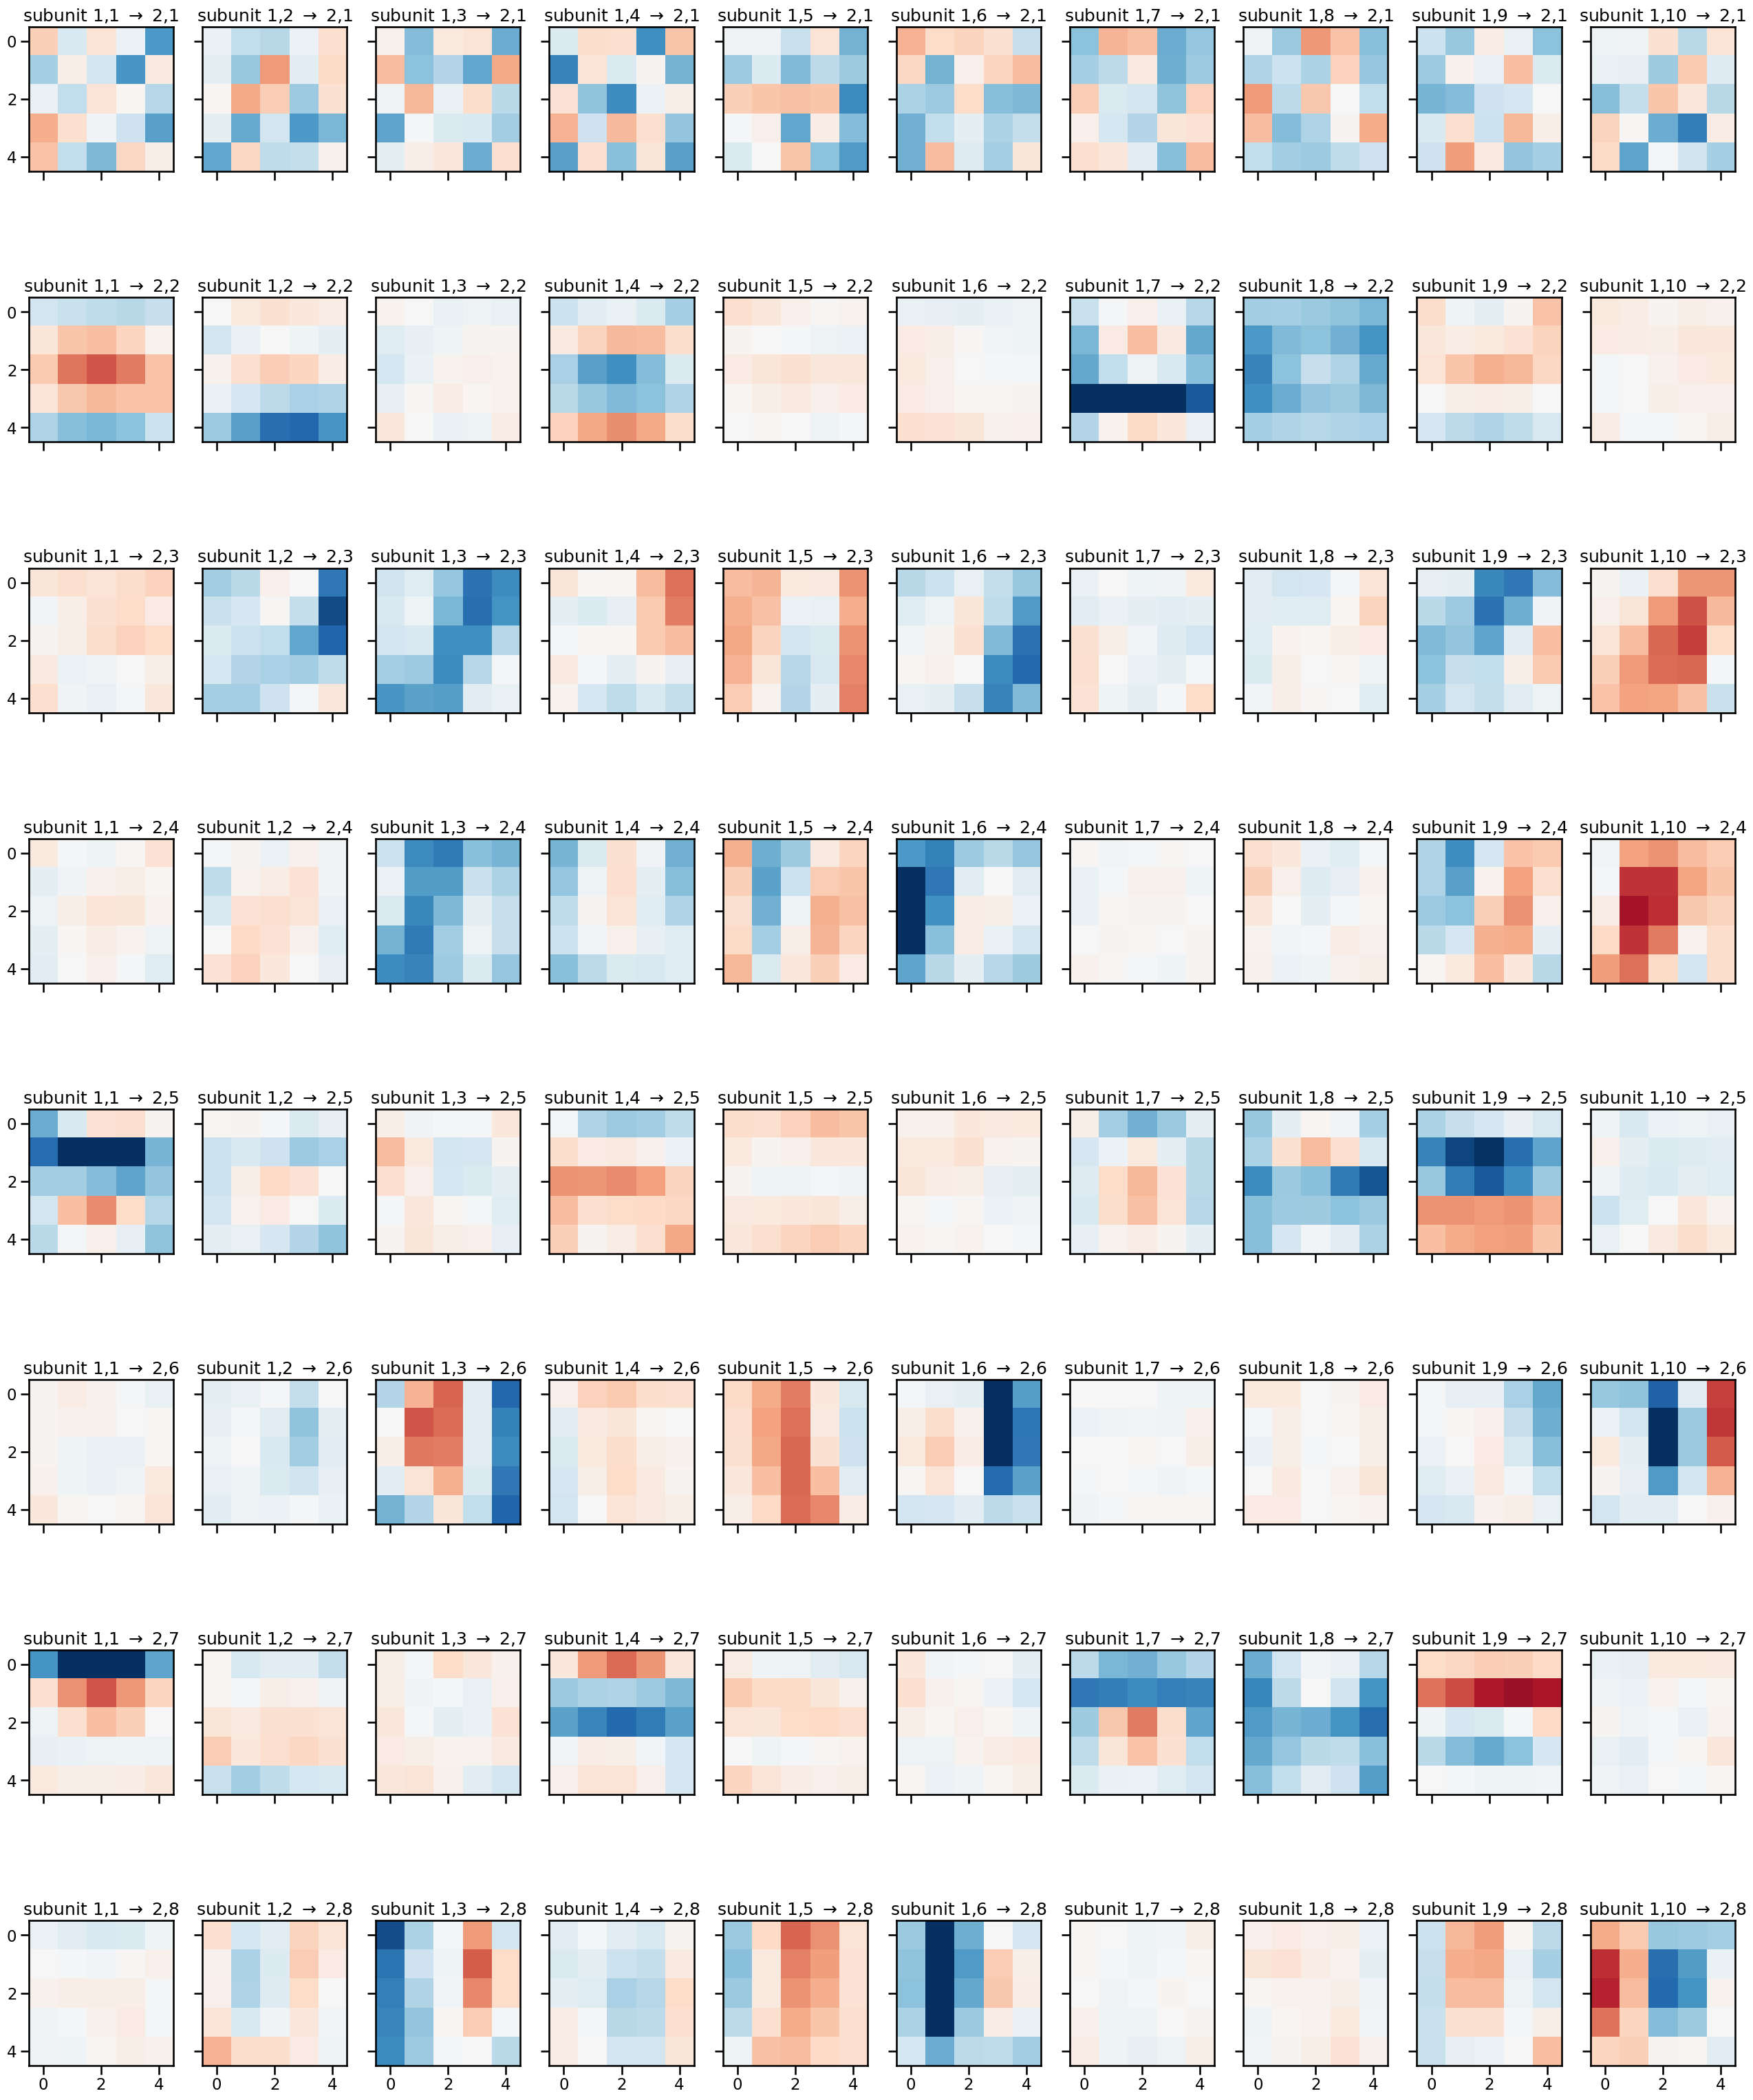

In [ ]:
plot_cnn_subunits2(model)

{'n_dead': 1, 'readout_consistency': 3.9209843066946144, 'opponency': -0.9887960042272296}


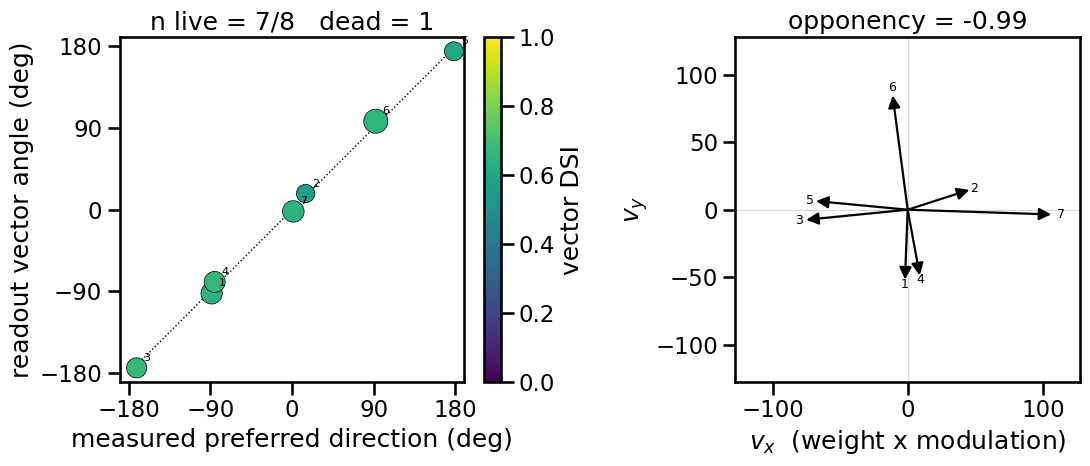

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch


@torch.no_grad()
def readout_summary(model, res, V_STD, amp_frac=0.05):
    """Readout vectors vs measured tuning.

    model : trained CNN (rows of model.readout are normalized in forward)
    res   : dict from layer2_tuning(); needs "tuning" (n_dir, N2) and "dsi" (N2,)
    V_STD : per-axis velocity std used to standardize targets (tensor or array, len 2)

    Returns (fig, summary). Angles are in LABEL space (gaze velocity);
    add 180 deg before comparing with T4/T5 preferred directions.
    """
    tun = np.asarray(res["tuning"])                       # (n_dir, N2)
    dsi = np.asarray(res["dsi"])
    n_dir, n_ch = tun.shape

    # --- continuous preferred direction (vector average, no bin quantization) ---
    th_bins = np.radians(np.linspace(-180, 180, n_dir, endpoint=False) + 180 / n_dir)
    z = (tun * np.exp(1j * th_bins)[:, None]).sum(0)      # (N2,)
    pref = np.degrees(np.angle(z))
    vdsi = np.abs(z) / (tun.sum(0) + 1e-12)               # vector DSI, 0 = untuned

    # --- modulation depth: who actually carries signal ---
    amp = tun.max(0) - tun.min(0)
    live = amp > amp_frac * amp.max()

    # --- readout vectors, rescaled to physical units ---
    W = (model.readout / model.readout.norm(dim=1, keepdim=True)).detach().cpu().numpy()
    vstd = V_STD.detach().cpu().numpy() if torch.is_tensor(V_STD) else np.asarray(V_STD)
    Wp = W * vstd[:, None]                                # undo per-axis standardization
    w_ang = np.degrees(np.arctan2(Wp[1], Wp[0]))
    w_len = np.linalg.norm(Wp, axis=0)
    contrib = w_len * amp                                 # effective contribution

    # --- opponency: for each live channel, its most-opposite partner by tuning ---
    d = np.abs(((pref[:, None] - pref[None, :] + 180) % 360) - 180)   # pairwise |Δpref|
    d[~live] = -1; d[:, ~live] = -1
    np.fill_diagonal(d, -1)
    opp = []
    for k in np.where(live)[0]:
        j = int(np.argmax(d[k]))
        if d[k, j] < 120:                                 # no true opposite partner
            continue
        a, b = Wp[:, k], Wp[:, j]
        opp.append(float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12)))
    opponency = float(np.mean(opp)) if opp else np.nan     # -> -1 when opponent

    # ---------------- figure ----------------
    fig, ax = plt.subplots(1, 2, figsize=(11.5, 5))

    # (a) readout angle vs measured preferred direction
    sc = ax[0].scatter(pref[live], w_ang[live],
                       s=40 + 260 * amp[live] / amp.max(),
                       c=vdsi[live], cmap="viridis", vmin=0, vmax=1,
                       edgecolor="k", linewidth=0.5, zorder=3)
    ax[0].plot([-180, 180], [-180, 180], "k:", lw=1, zorder=1)
    for k in np.where(live)[0]:
        ax[0].annotate(str(k), (pref[k], w_ang[k]), fontsize=8,
                       xytext=(5, 5), textcoords="offset points")
    ax[0].set(xlabel="measured preferred direction (deg)",
              ylabel="readout vector angle (deg)",
              xlim=(-190, 190), ylim=(-190, 190),
              xticks=[-180, -90, 0, 90, 180], yticks=[-180, -90, 0, 90, 180],
              title=f"n live = {live.sum()}/{n_ch}   dead = {(~live).sum()}")
    ax[0].set_aspect("equal")
    plt.colorbar(sc, ax=ax[0], label="vector DSI", fraction=0.046)

    # (b) effective contribution of each channel
    lim = 1.2 * contrib[live].max()
    for k in np.argsort(-contrib):
        if not live[k]:
            continue
        a = np.radians(w_ang[k])
        ax[1].annotate("", xy=(contrib[k] * np.cos(a), contrib[k] * np.sin(a)),
                       xytext=(0, 0),
                       arrowprops=dict(arrowstyle="-|>", lw=1.6, color="k",
                                       shrinkA=0, shrinkB=0))
        ax[1].text(1.07 * contrib[k] * np.cos(a), 1.07 * contrib[k] * np.sin(a),
                   str(k), fontsize=9, ha="center", va="center")
    ax[1].axhline(0, c="0.85", lw=0.8, zorder=0)
    ax[1].axvline(0, c="0.85", lw=0.8, zorder=0)
    ax[1].set(xlim=(-lim, lim), ylim=(-lim, lim),
              xlabel="$v_x$  (weight x modulation)", ylabel="$v_y$",
              title=f"opponency = {opponency:.2f}")
    ax[1].set_aspect("equal")

    fig.tight_layout()

    summary = dict(pref_deg=pref.round(1).tolist(),
                   vdsi=vdsi.round(3).tolist(),
                   readout_deg=w_ang.round(1).tolist(),
                   modulation=amp.round(3).tolist(),
                   contribution=contrib.round(4).tolist(),
                   n_dead=int((~live).sum()),
                   readout_consistency=float(np.abs(
                       ((pref[live] - w_ang[live] + 180) % 360) - 180).mean()),
                   opponency=opponency)
    return fig, summary

res = layer2_tuning(model, val_dl)
fig, rsum = readout_summary(model, res, V_STD)
print({k: v for k, v in rsum.items()
       if k in ("n_dead", "readout_consistency", "opponency")})

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def polar_tuning(res, ncols=4, amp_frac=0.05, cmap=plt.cm.twilight_shifted):
    """Polar tuning curves for layer-2 channels.

    res : dict from layer2_tuning(); needs "tuning" (n_dir, N2) and "dsi" (N2,)

    Angles are in LABEL space (gaze velocity). Image motion is 180 deg opposite,
    and y is rows-down in the dataset convention, so "up" on this plot is +row.
    """
    tun = np.asarray(res["tuning"])
    dsi = np.asarray(res["dsi"])
    n_dir, n_ch = tun.shape

    th = np.radians(np.linspace(-180, 180, n_dir, endpoint=False) + 180 / n_dir)
    thc = np.append(th, th[0])                       # close the curve
    tunc = np.vstack([tun, tun[:1]])                 # (n_dir+1, N2)

    z = (tun * np.exp(1j * th)[:, None]).sum(0)
    pref = np.angle(z)
    vdsi = np.abs(z) / (tun.sum(0) + 1e-12)
    amp = tun.max(0) - tun.min(0)
    live = amp > amp_frac * amp.max()
    col = cmap((np.degrees(pref) % 360) / 360)
    rmax = 1.05 * tun.max()

    nrows = int(np.ceil(n_ch / ncols))
    fig = plt.figure(figsize=(4.8 + 2.3 * ncols, max(5.0, 2.3 * nrows)))
    gs = fig.add_gridspec(nrows, ncols + 2, wspace=0.45, hspace=0.45)

    # ---------------- combined ----------------
    axc = fig.add_subplot(gs[:, :2], projection="polar")
    for k in range(n_ch):
        if not live[k]:
            continue
        axc.plot(thc, tunc[:, k], color=col[k], lw=2, label=f"{k}")
        axc.annotate("", xy=(pref[k], tun[:, k].max()), xytext=(0, 0),
                     arrowprops=dict(arrowstyle="-|>", color=col[k], lw=1.4,
                                     shrinkA=0, shrinkB=0, alpha=0.7))
    axc.set(ylim=(0, rmax), title="all live channels")
    axc.set_xticks(np.radians([0, 45, 90, 135, 180, 225, 270, 315]))
    axc.set_yticklabels([])
    axc.grid(alpha=0.3)
    axc.legend(loc="upper left", bbox_to_anchor=(1.02, 1.05),
               fontsize=8, frameon=False, title="ch")

    # ---------------- small multiples ----------------
    for k in range(n_ch):
        ax = fig.add_subplot(gs[k // ncols, 2 + k % ncols], projection="polar")
        c = col[k] if live[k] else "0.75"
        ax.fill(thc, tunc[:, k], color=c, alpha=0.30)
        ax.plot(thc, tunc[:, k], color=c, lw=1.8)
        if live[k]:
            ax.annotate("", xy=(pref[k], tun[:, k].max()), xytext=(0, 0),
                        arrowprops=dict(arrowstyle="-|>", color="k", lw=1.2,
                                        shrinkA=0, shrinkB=0))
        ax.set_ylim(0, rmax)
        ax.set_xticks(np.radians([0, 90, 180, 270]))
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.grid(alpha=0.25)
        ax.set_title(f"ch {k}" + ("  (dead)" if not live[k] else
                     f"\nDSI {dsi[k]:.2f} · vDSI {vdsi[k]:.2f}\n{np.degrees(pref[k]):+.0f}°"),
                     fontsize=8.5, pad=8)

    fig.suptitle("Layer-2 direction tuning (label space; image motion is 180° opposite)",
                 y=0.995, fontsize=11)
    return fig

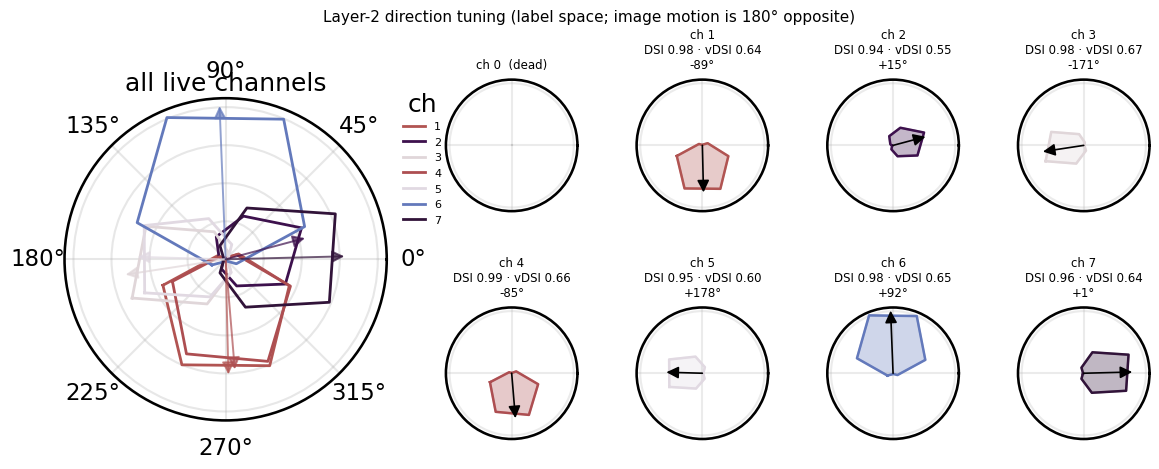

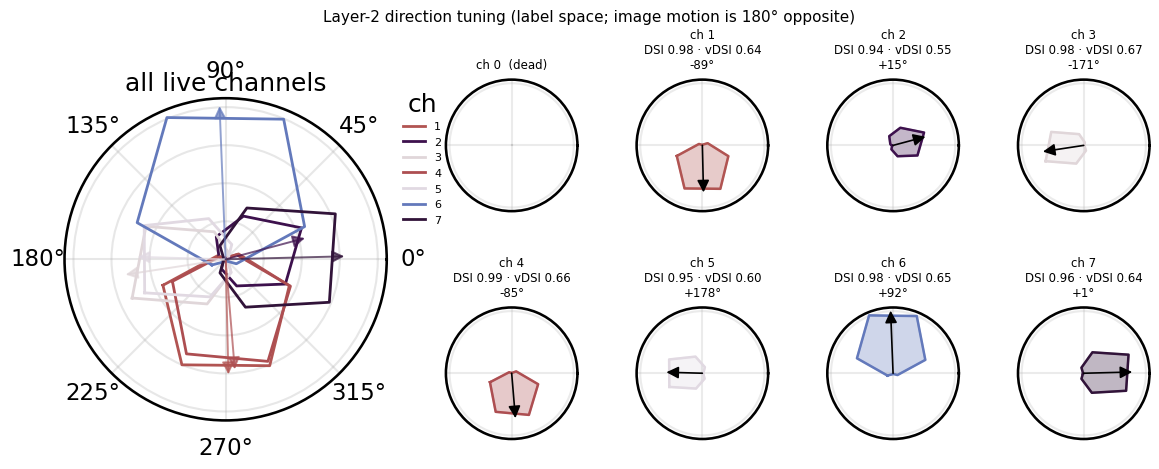

In [ ]:
res = layer2_tuning(model, val_dl)
polar_tuning(res)